# Solutions: Network Properties & Centrality Analysis
*This notebook contains the solutions to the exercises presented at the end of Notebook 2.*


### Environment Setup
Run this cell to import the necessary libraries and recreate the graph `G` used in the exercises.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Configure visual styling
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Recreate the collaboration network (G) from Notebook 2 for Exercise 3
G = nx.Graph()
edges = [
    ("Alice", "Bob", 4), ("Alice", "Charlie", 2), ("Bob", "Charlie", 1),
    ("Bob", "Diana", 5), ("Charlie", "Diana", 2), ("Charlie", "Eve", 3),
    ("Diana", "Eve", 2), ("Diana", "Frank", 6), ("Eve", "Frank", 3),
    ("Frank", "Gita", 4), ("Gita", "Hank", 2)
]
G.add_weighted_edges_from(edges)
print("Environment setup complete.")


Environment setup complete.


---
### Solution 1: Finding Network Bottlenecks
**Goal:** Analyze a Barabási-Albert graph to find its diameter, path length, and biggest gatekeeper.


In [2]:
# 1. Generate the Barabási-Albert graph
G_ba = nx.barabasi_albert_graph(n=30, m=2, seed=42)

# 2. Compute Diameter and Average Shortest Path Length
diameter = nx.diameter(G_ba)
avg_path = nx.average_shortest_path_length(G_ba)

print(f"Network Diameter: {diameter}")
print(f"Average Shortest Path Length: {avg_path:.4f}")
print("-" * 30)

# 3. Identify the node with highest Betweenness Centrality
bw_centrality = nx.betweenness_centrality(G_ba)
max_bw_node = max(bw_centrality, key=bw_centrality.get)
max_bw_score = bw_centrality[max_bw_node]

# Get the first 3 neighbors of this node
top_neighbors = list(G_ba.neighbors(max_bw_node))[:3]

print(f"Node with highest Betweenness: Node {max_bw_node} (Score: {max_bw_score:.4f})")
print(f"Top 3 neighbors of Node {max_bw_node}: {top_neighbors}")


Network Diameter: 4
Average Shortest Path Length: 2.1816
------------------------------
Node with highest Betweenness: Node 0 (Score: 0.4698)
Top 3 neighbors of Node 0: [1, 2, 3]


---
### Solution 2: Directed Citation Authority
**Goal:** Build a citation network and use PageRank to find the most foundational paper.


In [3]:
# 1. Construct the directed citation network
citation_graph = nx.DiGraph()

# 2. Add directed edges (Paper A cites Paper B)
# In this structure, Paper_1 is cited by almost everyone directly or indirectly.
citations = [
    ("Paper_6", "Paper_1"),
    ("Paper_5", "Paper_1"),
    ("Paper_4", "Paper_1"),
    ("Paper_3", "Paper_2"),
    ("Paper_2", "Paper_1"),
    ("Paper_5", "Paper_2")
]
citation_graph.add_edges_from(citations)

# 3. Compute PageRank
pagerank_scores = nx.pagerank(citation_graph, alpha=0.85)

# Format into a DataFrame for clean viewing
pr_df = pd.DataFrame(list(pagerank_scores.items()), columns=["Paper", "PageRank Score"])
pr_df = pr_df.sort_values(by="PageRank Score", ascending=False).reset_index(drop=True)

print(pr_df)
print("\n--- Conclusion ---")
print("Paper_1 emerges as the seminal foundational reference because it has the highest PageRank score.")
print("This happens because it receives the highest quantity of direct citations, and importantly, it receives citations from other highly-cited papers (like Paper_2).")


     Paper  PageRank Score
0  Paper_1        0.446343
1  Paper_2        0.200728
2  Paper_6        0.088232
3  Paper_5        0.088232
4  Paper_4        0.088232
5  Paper_3        0.088232

--- Conclusion ---
Paper_1 emerges as the seminal foundational reference because it has the highest PageRank score.
This happens because it receives the highest quantity of direct citations, and importantly, it receives citations from other highly-cited papers (like Paper_2).


---
### Solution 3: Visualizing Critical Gatekeepers
**Goal:** Map Degree Centrality to node size, and Betweenness Centrality to node color.


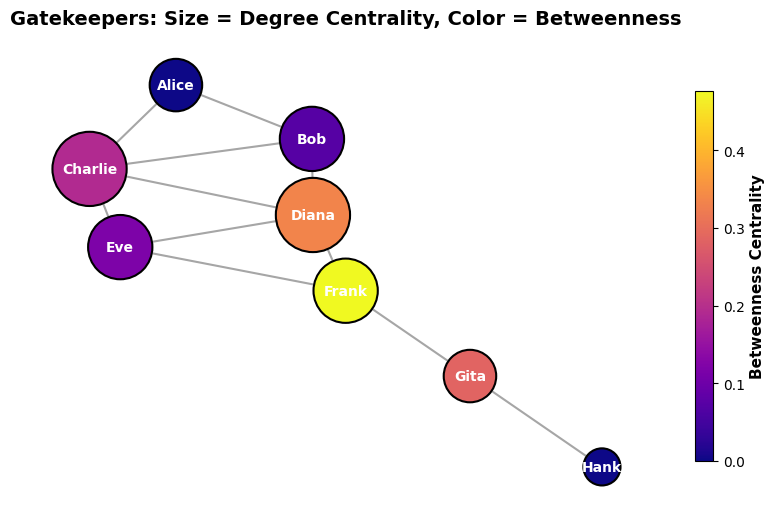

In [4]:
# 1. Compute Degree and Betweenness Centrality for Graph G
deg_centrality = nx.degree_centrality(G)
bet_centrality = nx.betweenness_centrality(G)

# 2. Produce the Visualization
plt.figure(figsize=(10, 6))

# Generate a layout
pos = nx.spring_layout(G, seed=42)

# Scale up degree centrality for node sizes (multiply by a constant for visual impact)
node_sizes = [5000 * deg_centrality[node] for node in G.nodes()]

# Extract betweenness values for the colormap
node_colors = [bet_centrality[node] for node in G.nodes()]

# Draw the edges
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.7, width=1.5)

# Draw the nodes using the 'plasma' colormap
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    edgecolors="black",
    linewidths=1.5
)

# Draw the labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", font_color="white")

# Add the Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation="vertical", shrink=0.8)
cbar.set_label("Betweenness Centrality", fontsize=11, fontweight="bold")

# 3. Display with title
plt.title("Gatekeepers: Size = Degree Centrality, Color = Betweenness", fontsize=14, fontweight="bold", pad=15)
plt.axis("off")
plt.show()
